# ASL Sign Language Recognition with WLASL Dataset

This notebook trains a sign language recognition model using:
- **WLASL** dataset with pre-extracted MediaPipe landmarks
- **LSTM/Transformer** for temporal sequence classification
- **Data augmentation** for improved generalization

## Setup on Kaggle
1. Add datasets:
   - `abd0kamel/mutemotion-output` (pre-extracted landmarks)
2. Enable GPU: Settings -> Accelerator -> GPU T4 x2 or P100
3. Run all cells

In [1]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.notebook import tqdm
from collections import defaultdict
import math
import matplotlib.pyplot as plt

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## 1. Configuration

In [2]:
# === CONFIGURATION ===

CONFIG = {
    # Data paths - using mutemotion-output dataset (pre-extracted landmarks)
    "landmarks_npz": "/kaggle/input/mutemotion-output/landmarks_V2.npz",  # 180 landmarks per frame
    "json_path": "/kaggle/input/mutemotion-output/WLASL_parsed_data.json",
    
    # Landmark configuration
    # V2/V3 format: Right Hand (21) + Left Hand (21) + Pose (6) + Face (132) = 180 landmarks
    "use_hands_only": False,  # If True, use only 42 hand landmarks (21*2)
    "use_hands_pose": False,  # If True, use hands + pose = 48 landmarks
    # When both are False, uses ALL 180 landmarks (hands + pose + face)
    
    # Dataset settings - WLASL300 for more data
    "num_classes": 300,  # WLASL300 - more data, harder task
    "max_seq_length": 60,  # Max frames per video
    
    # Model settings
    "model_type": "lstm_attention",  # "lstm", "lstm_attention", "transformer"
    "hidden_dim": 256,
    "num_layers": 2,
    "dropout": 0.5,  # Higher dropout to reduce overfitting
    
    # Training settings
    "batch_size": 32,
    "learning_rate": 0.0005,  # Lower learning rate for stability
    "epochs": 100,
    "early_stopping_patience": 15,
    
    # Augmentation
    "augment": True,
    "augment_multiplier": 2,
}

# Calculate input dimension based on landmark selection
if CONFIG["use_hands_only"]:
    CONFIG["input_dim"] = 42 * 3  # 126
    CONFIG["landmark_indices"] = list(range(42))
elif CONFIG["use_hands_pose"]:
    CONFIG["input_dim"] = 48 * 3  # 144
    CONFIG["landmark_indices"] = list(range(48))
else:
    CONFIG["input_dim"] = 180 * 3  # 540 (all landmarks including face)
    CONFIG["landmark_indices"] = list(range(180))

print(f"Using {len(CONFIG['landmark_indices'])} landmarks -> input_dim = {CONFIG['input_dim']}")
print(f"Training on WLASL{CONFIG['num_classes']}")
print(f"Includes: Hands (42) + Pose (6) + Face (132) = 180 landmarks")

os.makedirs("/kaggle/working/checkpoints", exist_ok=True)

Using 180 landmarks -> input_dim = 540
Training on WLASL300
Includes: Hands (42) + Pose (6) + Face (132) = 180 landmarks


## 2. Load Pre-extracted Landmarks

In [3]:
# List available files
print("Available files in mutemotion-output:")
!ls -lh /kaggle/input/mutemotion-output/

Available files in mutemotion-output:
total 14G
-rw-r--r-- 1 nobody nogroup 2.2K Nov 28 14:46 filtered_labels.txt
-rw-r--r-- 1 nobody nogroup 2.6M Nov 28 14:46 labels.npz
-rw-r--r-- 1 nobody nogroup 2.6G Nov 28 14:46 landmarks_V1.npz
-rw-r--r-- 1 nobody nogroup 2.6G Nov 28 14:46 landmarks_V2.npz
-rw-r--r-- 1 nobody nogroup 8.4G Nov 28 14:54 landmarks_V3.npz
-rw-r--r-- 1 nobody nogroup 4.0M Nov 28 14:46 WLASL_parsed_data.json


In [4]:
# Load pre-extracted landmarks into memory (avoids NPZ multiprocessing issues)
print("Loading pre-extracted landmarks into memory...")
landmarks_npz = np.load(CONFIG["landmarks_npz"], allow_pickle=True)

# Convert to regular dict to avoid BadZipFile errors with DataLoader workers
landmarks_data = {key: landmarks_npz[key] for key in tqdm(landmarks_npz.files, desc="Loading")}
landmarks_npz.close()  # Close the NPZ file
print(f"Loaded {len(landmarks_data)} video landmarks into memory")

# Check shape of first sample
sample_key = list(landmarks_data.keys())[0]
sample = landmarks_data[sample_key]
print(f"Sample shape: {sample.shape}  (frames, landmarks, coords)")

Loading pre-extracted landmarks into memory...


Loading:   0%|          | 0/21083 [00:00<?, ?it/s]

Loaded 21083 video landmarks into memory
Sample shape: (81, 180, 3)  (frames, landmarks, coords)


In [5]:
# Load parsed annotations
with open(CONFIG["json_path"], 'r') as f:
    parsed_data = json.load(f)

print(f"Total samples in JSON: {len(parsed_data)}")
print(f"\nSample entry:")
print(json.dumps(parsed_data[0], indent=2))

Total samples in JSON: 21083

Sample entry:
{
  "gloss": "book",
  "video_path": "/kaggle/input/wlasl-processed/videos/69241.mp4",
  "frame_start": 1,
  "frame_end": -1,
  "split": "train"
}


In [6]:
# Count glosses and find top N
gloss_counts = defaultdict(int)
for entry in parsed_data:
    gloss_counts[entry['gloss']] += 1

print(f"Total unique glosses: {len(gloss_counts)}")

# Get top N glosses
sorted_glosses = sorted(gloss_counts.items(), key=lambda x: -x[1])
top_glosses = [g for g, c in sorted_glosses[:CONFIG["num_classes"]]]

print(f"\nTop 10 glosses:")
for gloss, count in sorted_glosses[:10]:
    print(f"  {gloss}: {count} samples")

Total unique glosses: 2000

Top 10 glosses:
  book: 40 samples
  drink: 35 samples
  computer: 30 samples
  before: 26 samples
  chair: 26 samples
  go: 26 samples
  clothes: 25 samples
  who: 25 samples
  candy: 24 samples
  cousin: 23 samples


## 3. Data Augmentation

In [7]:
# Augmentation functions (adapted from MuteMotion notebook)

def rotate(data, rotation_matrix):
    """Apply rotation matrix to landmarks."""
    frames, landmarks, _ = data.shape
    center = np.array([0.5, 0.5, 0])
    
    # Find non-zero landmarks
    non_zero_mask = np.any(data[:, :, :2] != 0, axis=2)
    
    result = data.copy()
    for f in range(frames):
        for l in range(landmarks):
            if non_zero_mask[f, l]:
                point = result[f, l] - center
                point = np.dot(rotation_matrix, point)
                result[f, l] = point + center
    
    # Zero out points that went out of range
    out_of_range = np.any((result[:, :, :2] < 0) | (result[:, :, :2] > 1), axis=2)
    result[out_of_range] = 0
    return result

def rotate_z(data):
    """Rotate around Z axis (in-plane rotation)."""
    angle = np.random.uniform(-20, 20)
    theta = np.radians(angle)
    rotation_matrix = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta), np.cos(theta), 0],
        [0, 0, 1]
    ])
    return rotate(data, rotation_matrix)

def zoom(data):
    """Random zoom in/out."""
    factor = np.random.uniform(0.85, 1.15)
    center = np.array([0.5, 0.5])
    result = data.copy()
    
    non_zero_mask = np.any(data[:, :, :2] != 0, axis=2)
    for f in range(data.shape[0]):
        for l in range(data.shape[1]):
            if non_zero_mask[f, l]:
                result[f, l, :2] = (data[f, l, :2] - center) * factor + center
    
    out_of_range = np.any((result[:, :, :2] < 0) | (result[:, :, :2] > 1), axis=2)
    result[out_of_range] = 0
    return result

def shift(data):
    """Random translation."""
    x_shift = np.random.uniform(-0.1, 0.1)
    y_shift = np.random.uniform(-0.1, 0.1)
    result = data.copy()
    
    non_zero_mask = np.any(data[:, :, :2] != 0, axis=2)
    result[non_zero_mask, 0] += x_shift
    result[non_zero_mask, 1] += y_shift
    
    out_of_range = np.any((result[:, :, :2] < 0) | (result[:, :, :2] > 1), axis=2)
    result[out_of_range] = 0
    return result

def hflip(data):
    """Horizontal flip."""
    result = data.copy()
    result[:, :, 0] = 1 - result[:, :, 0]
    return result

def temporal_crop(data):
    """Random temporal cropping (use 80-100% of frames)."""
    frames = data.shape[0]
    if frames <= 10:
        return data
    
    keep_ratio = np.random.uniform(0.8, 1.0)
    keep_frames = max(10, int(frames * keep_ratio))
    start = np.random.randint(0, frames - keep_frames + 1)
    return data[start:start + keep_frames]

def speed_change(data):
    """Random speed change by frame skipping/interpolation."""
    frames = data.shape[0]
    if frames <= 10:
        return data
    
    # Speed up (skip frames)
    if np.random.rand() < 0.5:
        skip = np.random.choice([2, 3])
        return data[::skip]
    return data

def apply_augmentation(data):
    """Apply random augmentations to landmark sequence."""
    result = data.copy()
    
    # Apply each augmentation with some probability
    if np.random.rand() < 0.5:
        result = rotate_z(result)
    if np.random.rand() < 0.5:
        result = zoom(result)
    if np.random.rand() < 0.5:
        result = shift(result)
    if np.random.rand() < 0.3:
        result = hflip(result)
    if np.random.rand() < 0.3:
        result = temporal_crop(result)
    if np.random.rand() < 0.3:
        result = speed_change(result)
    
    return result

print("Augmentation functions defined.")

Augmentation functions defined.


## 4. Dataset and DataLoader

In [8]:
class WLASLDataset(Dataset):
    """
    PyTorch Dataset for WLASL using pre-extracted landmarks.
    """
    
    def __init__(self, indices, parsed_data, landmarks_data, gloss_to_idx, 
                 landmark_indices, max_seq_length=60, augment=False):
        """
        Args:
            indices: List of indices into parsed_data for this split
            parsed_data: Full parsed JSON data
            landmarks_data: Dict of landmarks (key: str index, value: numpy array)
            gloss_to_idx: Dict mapping gloss to class index
            landmark_indices: Which landmarks to use (e.g., [0-47] for hands+pose)
            max_seq_length: Pad/truncate to this length
            augment: Whether to apply data augmentation
        """
        self.parsed_data = parsed_data
        self.landmarks_data = landmarks_data
        self.gloss_to_idx = gloss_to_idx
        self.landmark_indices = landmark_indices
        self.max_seq_length = max_seq_length
        self.augment = augment
        
        # Filter to valid samples
        self.valid_indices = []
        for idx in indices:
            gloss = parsed_data[idx]['gloss']
            if gloss in gloss_to_idx and str(idx) in landmarks_data:
                self.valid_indices.append(idx)
        
    def __len__(self):
        return len(self.valid_indices)
    
    def __getitem__(self, idx):
        data_idx = self.valid_indices[idx]
        entry = self.parsed_data[data_idx]
        gloss = entry['gloss']
        label = self.gloss_to_idx[gloss]
        
        # Load landmarks from dict: shape (frames, 180, 3)
        landmarks = self.landmarks_data[str(data_idx)].copy()
        
        # Select subset of landmarks
        landmarks = landmarks[:, self.landmark_indices, :]
        
        # Apply augmentation
        if self.augment:
            landmarks = apply_augmentation(landmarks)
        
        # Flatten: (frames, N, 3) -> (frames, N*3)
        landmarks = landmarks.reshape(landmarks.shape[0], -1)
        
        # Pad or truncate
        landmarks = self._pad_or_truncate(landmarks)
        
        return torch.tensor(landmarks, dtype=torch.float32), label
    
    def _pad_or_truncate(self, seq):
        """Pad with zeros or uniformly sample to max_seq_length."""
        T = seq.shape[0]
        
        if T > self.max_seq_length:
            # Uniform sampling
            indices = np.linspace(0, T - 1, self.max_seq_length, dtype=int)
            return seq[indices]
        elif T < self.max_seq_length:
            # Pad with zeros
            padding = np.zeros((self.max_seq_length - T, seq.shape[1]))
            return np.vstack([seq, padding])
        return seq

In [9]:
def create_data_splits(parsed_data, landmarks_data, num_classes=100):
    """
    Create train/val/test splits using official WLASL splits.
    """
    # Get top N glosses by count
    gloss_counts = defaultdict(int)
    for i, entry in enumerate(parsed_data):
        if str(i) in landmarks_data:  # Only count if we have landmarks
            gloss_counts[entry['gloss']] += 1
    
    sorted_glosses = sorted(gloss_counts.items(), key=lambda x: -x[1])
    top_glosses = [g for g, c in sorted_glosses[:num_classes]]
    top_glosses_set = set(top_glosses)
    
    # Create mappings
    gloss_to_idx = {g: i for i, g in enumerate(top_glosses)}
    idx_to_gloss = {i: g for g, i in gloss_to_idx.items()}
    
    # Split by official splits
    train_indices = []
    val_indices = []
    test_indices = []
    
    for i, entry in enumerate(parsed_data):
        gloss = entry['gloss']
        split = entry.get('split', 'train')
        
        if gloss not in top_glosses_set:
            continue
        if str(i) not in landmarks_data:
            continue
        
        if split == 'train':
            train_indices.append(i)
        elif split == 'val':
            val_indices.append(i)
        elif split == 'test':
            test_indices.append(i)
        else:
            train_indices.append(i)
    
    print(f"Classes: {len(gloss_to_idx)}")
    print(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")
    
    return train_indices, val_indices, test_indices, gloss_to_idx, idx_to_gloss

# Create splits
train_indices, val_indices, test_indices, gloss_to_idx, idx_to_gloss = create_data_splits(
    parsed_data, landmarks_data, CONFIG["num_classes"]
)

Classes: 300
Train: 3549, Val: 900, Test: 668


In [10]:
# Create datasets
train_dataset = WLASLDataset(
    train_indices, parsed_data, landmarks_data, gloss_to_idx,
    CONFIG["landmark_indices"], CONFIG["max_seq_length"], 
    augment=CONFIG["augment"]
)

val_dataset = WLASLDataset(
    val_indices, parsed_data, landmarks_data, gloss_to_idx,
    CONFIG["landmark_indices"], CONFIG["max_seq_length"],
    augment=False
)

test_dataset = WLASLDataset(
    test_indices, parsed_data, landmarks_data, gloss_to_idx,
    CONFIG["landmark_indices"], CONFIG["max_seq_length"],
    augment=False
)

# Create data loaders (num_workers=0 to avoid multiprocessing issues with shared data)
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

print(f"\nDataset sizes:")
print(f"  Train: {len(train_dataset)}")
print(f"  Val: {len(val_dataset)}")
print(f"  Test: {len(test_dataset)}")


Dataset sizes:
  Train: 3549
  Val: 900
  Test: 668


Sample shape: torch.Size([60, 540])
Label: 0 (book)


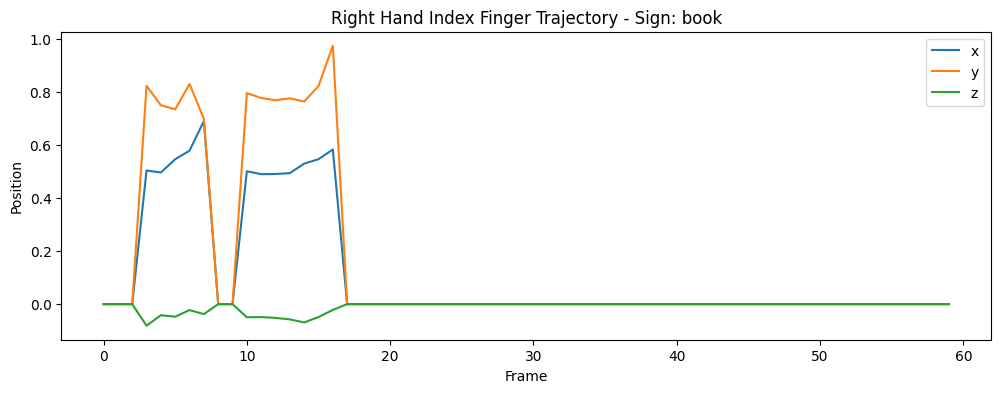

In [11]:
# Visualize a sample
sample_x, sample_y = train_dataset[0]
print(f"Sample shape: {sample_x.shape}")
print(f"Label: {sample_y} ({idx_to_gloss[sample_y]})")

# Plot landmark trajectory for index finger tip (landmark 8 of right hand)
plt.figure(figsize=(12, 4))
landmark_idx = 8  # Index finger tip
plt.plot(sample_x[:, landmark_idx*3].numpy(), label='x')
plt.plot(sample_x[:, landmark_idx*3+1].numpy(), label='y')
plt.plot(sample_x[:, landmark_idx*3+2].numpy(), label='z')
plt.title(f"Right Hand Index Finger Trajectory - Sign: {idx_to_gloss[sample_y]}")
plt.xlabel("Frame")
plt.ylabel("Position")
plt.legend()
plt.show()

## 5. Model Definitions

In [12]:
class SignLSTM(nn.Module):
    """Bidirectional LSTM for sign language classification."""
    
    def __init__(self, input_dim=144, hidden_dim=256, num_layers=2, 
                 num_classes=100, dropout=0.3, bidirectional=True):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )
        
        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_output_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        if self.bidirectional:
            forward_h = h_n[-2, :, :]
            backward_h = h_n[-1, :, :]
            hidden = torch.cat([forward_h, backward_h], dim=1)
        else:
            hidden = h_n[-1, :, :]
        
        return self.fc(hidden)


class SignLSTMWithAttention(nn.Module):
    """LSTM with temporal attention mechanism."""
    
    def __init__(self, input_dim=144, hidden_dim=256, num_layers=2,
                 num_classes=100, dropout=0.3):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        
        lstm_output_dim = hidden_dim * 2
        
        self.attention = nn.Sequential(
            nn.Linear(lstm_output_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_output_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_scores = self.attention(lstm_out)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        return self.fc(context)

In [13]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for transformer."""
    
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class SignTransformer(nn.Module):
    """Transformer encoder for sign language classification."""
    
    def __init__(self, input_dim=144, d_model=256, nhead=8, num_layers=4,
                 dim_feedforward=512, num_classes=100, dropout=0.1, max_seq_length=200):
        super().__init__()
        
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_seq_length, dropout)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.fc = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )
        
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
    
    def forward(self, x):
        batch_size = x.size(0)
        x = self.input_projection(x)
        
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        
        cls_output = x[:, 0, :]
        return self.fc(cls_output)

In [14]:
def create_model(model_type, num_classes, config):
    """Create model based on type."""
    if model_type == 'lstm':
        return SignLSTM(
            input_dim=config["input_dim"],
            hidden_dim=config["hidden_dim"],
            num_layers=config["num_layers"],
            num_classes=num_classes,
            dropout=config["dropout"]
        )
    elif model_type == 'lstm_attention':
        return SignLSTMWithAttention(
            input_dim=config["input_dim"],
            hidden_dim=config["hidden_dim"],
            num_layers=config["num_layers"],
            num_classes=num_classes,
            dropout=config["dropout"]
        )
    elif model_type == 'transformer':
        return SignTransformer(
            input_dim=config["input_dim"],
            d_model=config["hidden_dim"],
            num_classes=num_classes,
            dropout=config["dropout"]
        )
    else:
        raise ValueError(f"Unknown model type: {model_type}")

# Create model
num_classes = len(gloss_to_idx)
model = create_model(CONFIG["model_type"], num_classes, CONFIG)
model = model.to(device)

print(f"Model: {CONFIG['model_type']}")
print(f"Input dim: {CONFIG['input_dim']}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model: lstm_attention
Input dim: 540
Parameters: 3,551,277


## 6. Training

In [15]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_x, batch_y in tqdm(train_loader, desc="Training", leave=False):
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(batch_y).sum().item()
        total += batch_y.size(0)
    
    return total_loss / len(train_loader), correct / total


def evaluate(model, data_loader, criterion, device):
    """Evaluate model."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(batch_y).sum().item()
            total += batch_y.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    return total_loss / len(data_loader), correct / total, all_preds, all_labels

In [16]:
# Setup training
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5, verbose=True)

# Training history
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0
patience_counter = 0

print(f"Starting training for {CONFIG['epochs']} epochs...")
print(f"Augmentation: {CONFIG['augment']}")
print()

Starting training for 100 epochs...
Augmentation: True



/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [17]:
# Training loop
for epoch in range(CONFIG["epochs"]):
    print(f"Epoch {epoch + 1}/{CONFIG['epochs']}")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    
    scheduler.step(val_acc)
    
    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'gloss_to_idx': gloss_to_idx,
            'idx_to_gloss': idx_to_gloss,
            'config': CONFIG
        }, f"/kaggle/working/checkpoints/best_{CONFIG['model_type']}.pt")
        print(f"  -> Saved best model (val_acc: {val_acc:.4f})")
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= CONFIG["early_stopping_patience"]:
        print(f"\nEarly stopping at epoch {epoch + 1}")
        break
    
    print()

Epoch 1/100


Training:   0%|          | 0/111 [00:00<?, ?it/s]

  Train Loss: 5.7111, Train Acc: 0.0023
  Val Loss: 5.7028, Val Acc: 0.0067
  -> Saved best model (val_acc: 0.0067)

Epoch 2/100


Training:   0%|          | 0/111 [00:00<?, ?it/s]

  Train Loss: 5.7010, Train Acc: 0.0079
  Val Loss: 5.6971, Val Acc: 0.0067

Epoch 3/100


...

  Train Loss: 4.5426, Train Acc: 0.0414
  Val Loss: 4.7357, Val Acc: 0.0378

Epoch 94/100


Training:   0%|          | 0/111 [00:00<?, ?it/s]

  Train Loss: 4.5427, Train Acc: 0.0417
  Val Loss: 4.7294, Val Acc: 0.0367

Epoch 95/100


Training:   0%|          | 0/111 [00:00<?, ?it/s]

  Train Loss: 4.5462, Train Acc: 0.0420
  Val Loss: 4.7295, Val Acc: 0.0356

Early stopping at epoch 95


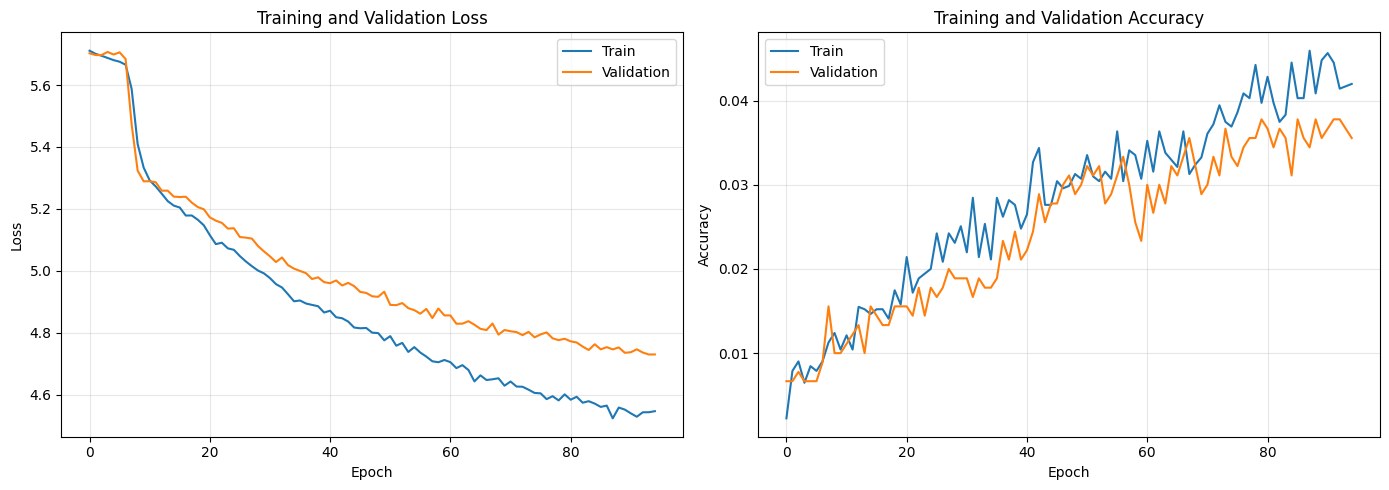

In [18]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', dpi=150)
plt.show()

## 7. Evaluation

In [19]:
# Load best model and evaluate on test set
checkpoint = torch.load(f"/kaggle/working/checkpoints/best_{CONFIG['model_type']}.pt")
model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print("=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy (Top-1): {test_acc:.4f}")

FINAL TEST RESULTS
Test Loss: 4.8587
Test Accuracy (Top-1): 0.0269


In [20]:
# Top-5 accuracy
def top_k_accuracy(model, data_loader, device, k=5):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            outputs = model(batch_x)
            _, top_k_preds = outputs.topk(k, dim=1)
            
            for i in range(batch_y.size(0)):
                if batch_y[i] in top_k_preds[i]:
                    correct += 1
                total += 1
    
    return correct / total

top5_acc = top_k_accuracy(model, test_loader, device, k=5)
print(f"Test Accuracy (Top-5): {top5_acc:.4f}")

Test Accuracy (Top-5): 0.1168


In [21]:
# Per-class accuracy
class_correct = defaultdict(int)
class_total = defaultdict(int)

for pred, label in zip(test_preds, test_labels):
    class_total[label] += 1
    if pred == label:
        class_correct[label] += 1

class_acc = {idx_to_gloss[k]: class_correct[k] / class_total[k] 
             for k in class_total if class_total[k] > 0}

# Sort by accuracy
sorted_acc = sorted(class_acc.items(), key=lambda x: -x[1])

print("\nTop 10 best recognized signs:")
for gloss, acc in sorted_acc[:10]:
    print(f"  {gloss}: {acc:.1%}")

print("\nTop 10 hardest signs:")
for gloss, acc in sorted_acc[-10:]:
    print(f"  {gloss}: {acc:.1%}")


Top 10 best recognized signs:
  forget: 100.0%
  book: 75.0%
  can: 50.0%
  time: 50.0%
  door: 50.0%
  headache: 50.0%
  learn: 50.0%
  sick: 50.0%
  example: 50.0%
  beard: 50.0%

Top 10 hardest signs:
  hurry: 0.0%
  improve: 0.0%
  internet: 0.0%
  jump: 0.0%
  kill: 0.0%
  law: 0.0%
  match: 0.0%
  meat: 0.0%
  milk: 0.0%
  money: 0.0%


## 8. Save Model for Local Demo

In [22]:
# Save final model with all metadata needed for demo
final_checkpoint = {
    'model_state_dict': model.state_dict(),
    'model_type': CONFIG['model_type'],
    'num_classes': num_classes,
    'gloss_to_idx': gloss_to_idx,
    'idx_to_gloss': idx_to_gloss,
    'config': CONFIG,
    'test_accuracy': test_acc,
    'top5_accuracy': top5_acc,
    'landmark_indices': CONFIG['landmark_indices']
}

torch.save(final_checkpoint, '/kaggle/working/sign_language_model.pt')
print("Model saved to /kaggle/working/sign_language_model.pt")
print("\nDownload this file and use it with your local demo.py script!")
print(f"\nNote: This model uses {len(CONFIG['landmark_indices'])} landmarks.")
print("Update your demo.py to extract the same landmarks.")

Model saved to /kaggle/working/sign_language_model.pt

Download this file and use it with your local demo.py script!

Note: This model uses 180 landmarks.
Update your demo.py to extract the same landmarks.


In [23]:
# Summary
print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
print(f"Model: {CONFIG['model_type']}")
print(f"Dataset: WLASL{CONFIG['num_classes']}")
print(f"Landmarks: {len(CONFIG['landmark_indices'])} (input_dim={CONFIG['input_dim']})")
print(f"Augmentation: {CONFIG['augment']}")
print(f"\nResults:")
print(f"  Best Val Accuracy: {best_val_acc:.4f}")
print(f"  Test Accuracy (Top-1): {test_acc:.4f}")
print(f"  Test Accuracy (Top-5): {top5_acc:.4f}")
print(f"\nFiles saved in /kaggle/working/:")
print("  - checkpoints/best_*.pt")
print("  - sign_language_model.pt")
print("  - training_history.png")


TRAINING COMPLETE
Model: lstm_attention
Dataset: WLASL300
Landmarks: 180 (input_dim=540)
Augmentation: True

Results:
  Best Val Accuracy: 0.0378
  Test Accuracy (Top-1): 0.0269
  Test Accuracy (Top-5): 0.1168

Files saved in /kaggle/working/:
  - checkpoints/best_*.pt
  - sign_language_model.pt
  - training_history.png


## 9. (Optional) Compare Models

In [24]:
# Uncomment to train and compare multiple models

# results = {}
# for model_type in ['lstm', 'lstm_attention', 'transformer']:
#     print(f"\n{'='*50}")
#     print(f"Training {model_type}...")
#     print('='*50)
#     
#     model = create_model(model_type, num_classes, CONFIG).to(device)
#     optimizer = Adam(model.parameters(), lr=CONFIG['learning_rate'])
#     
#     best_acc = 0
#     for epoch in range(20):  # Quick comparison
#         train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
#         val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
#         best_acc = max(best_acc, val_acc)
#         print(f"Epoch {epoch+1}: val_acc={val_acc:.4f}")
#     
#     test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)
#     results[model_type] = {'val': best_acc, 'test': test_acc}
#     print(f"{model_type} - best val: {best_acc:.4f}, test: {test_acc:.4f}")
# 
# print("\n" + "="*50)
# print("Model Comparison:")
# print("="*50)
# for model_type, accs in sorted(results.items(), key=lambda x: -x[1]['test']):
#     print(f"  {model_type}: val={accs['val']:.4f}, test={accs['test']:.4f}")